# 12: the discrete image

The image `Image.of(Original(x, y), basis, order)` carries `S = Phi^T y`
and `G = Phi^T Phi`, the projection of the data onto a basis and that
basis's Gram matrix over the sample grid. Claims:

1. `S` and `G` are exactly the products of the basis evaluated on the
   samples with `y` and with itself; nothing is smoothed or regularised
   into them. False if the rebuilt Gram differs from `Image.G` by more
   than a numerical tolerance on any of the three grid shapes.
2. Fitting on the image at the order `order_for` reports reproduces the
   pointwise fit: same rmse to three decimals, negligible bias, interval
   coverage inside a reasonable band, on a uniform, a clustered and a
   random grid. False if the rmse ratio departs from 1.000 by more than
   0.001 on any grid or family, if the relative bias exceeds 0.1 percent,
   or if coverage falls outside [0.88, 1.00].
3. Reading the same criterion by quadrature instead of on the samples
   throws away that parity, for two reasons that separate: a sum over the
   samples is not the rescaled integral even where the density is constant,
   and beyond that the mismatch grows with how uneven the grid is. False if
   the quadrature route does not read worse than the discrete one, or if it
   stays close to the discrete route's accuracy on the clustered grid, or
   if the endpoint terms that repair the uniform grid repair an uneven one
   too.
4. Order above what `order_for` reports is free: raising it further moves
   neither the ratio nor the coverage. Below that order a family whose
   sensitivities need more terms - the decaying oscillation, not the
   plain exponential - reads worse. False if the ratio or the coverage
   keeps moving materially above the reported order, or if the low-order
   departure does not show up on the oscillatory family.

The image's own conditioning by order and grid is notebook 13's; the
integral criterion's weight matrix is notebook 11's.

In [1]:
import os
import time
import warnings

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
from numpy.polynomial import legendre as leg
from scipy.optimize import least_squares

from dtfit.image import Image, Original, gram_whitener, make_basis, order_for, u_of
import dtfit
from dtfit_experimental.study import baselines, montecarlo, notebook

STARTED = time.time()
QUICK = os.environ.get("DTFIT_QUICK") == "1"
plt.rcParams["figure.dpi"] = 110

N = 200
REPS_FIT = 300
REPS_QUAD = 20 if QUICK else 200
REPS_ORDER = 20 if QUICK else 150
ORDERS = [4, 16, 96] if QUICK else [4, 8, 16, 24, 48, 96]
GRIDS = ("uniform", "clustered", "random")
QUAD_GRIDS = ("uniform", "clustered") if QUICK else GRIDS
print(f"QUICK={QUICK} N={N} REPS_FIT={REPS_FIT} REPS_QUAD={REPS_QUAD} "
      f"REPS_ORDER={REPS_ORDER} ORDERS={ORDERS} GRIDS={GRIDS} "
      f"QUAD_GRIDS={QUAD_GRIDS}")


QUICK=False N=200 REPS_FIT=300 REPS_QUAD=200 REPS_ORDER=150 ORDERS=[4, 8, 16, 24, 48, 96] GRIDS=('uniform', 'clustered', 'random') QUAD_GRIDS=('uniform', 'clustered', 'random')


## What the image holds

`Image.of` builds `S` and `G` from the basis evaluated on the samples;
rebuilding them by hand from `make_basis(...).evaluate(u_of(x, x0, x1))`
should give exactly the same arrays, since that evaluation is all `Image.of`
does before forming the two products. The order is fixed at 8 here, large
enough that the basis is not degenerate, small enough that a full matrix
comparison is cheap.


In [2]:
def model(x, a, b):
    return a * np.exp(b * x)


ORDER1 = 8
rows = []
for kind in GRIDS:
    rng = np.random.default_rng(0)
    x = montecarlo.grid(kind, N, span=1.0, rng=rng)
    y = model(x, 2.0, -1.3)
    img = Image.of(Original(x, y), "legendre", ORDER1)
    phi = make_basis("legendre", ORDER1).evaluate(u_of(x, 0.0, 1.0))
    g_diff = float(np.max(np.abs(phi.T @ phi - img.G)))
    s_diff = float(np.max(np.abs(phi.T @ y - img.S)))
    rows.append({"grid": kind, "order": ORDER1, "n": x.size,
                 "max_abs_G_diff": g_diff, "max_abs_S_diff": s_diff})
image_identity = pd.DataFrame(rows)
image_identity


,grid,order,n,max_abs_G_diff,max_abs_S_diff
0,uniform,8,200,2.486900e-14,0.0
1,clustered,8,200,1.776357e-14,0.0
2,random,8,200,2.842171e-14,0.0


In [3]:
# fails if the rebuilt Gram or projection is not the image's own to 1e-12
assert (image_identity.max_abs_G_diff < 1e-12).all()
assert (image_identity.max_abs_S_diff < 1e-12).all()
print("Phi^T Phi and Phi^T y rebuilt from the basis match Image.G and "
      f"Image.S to {image_identity.max_abs_G_diff.max():.1e} and "
      f"{image_identity.max_abs_S_diff.max():.1e} on all three grids.")
print("Image.beta is G^-1 S, not S: the samples are not orthonormal under "
      "the basis, so the raw projection S is not the least-squares "
      "coefficient until the Gram matrix is inverted out of it.")


Phi^T Phi and Phi^T y rebuilt from the basis match Image.G and Image.S to 2.8e-14 and 0.0e+00 on all three grids.
Image.beta is G^-1 S, not S: the samples are not orthonormal under the basis, so the raw projection S is not the least-squares coefficient until the Gram matrix is inverted out of it.


In [4]:
if QUICK:
    print("QUICK: skipping the CSV export")
else:
    notebook.save_table("12_discrete_image", "image_identity", image_identity)
    print("wrote experiments/results/12_discrete_image/image_identity.csv")


wrote experiments/results/12_discrete_image/image_identity.csv


## Grid shape and interval coverage at the reported order

`order_for(model, params, domain, param_names=...)` reports the smallest
Legendre order at which the model's own sensitivities are represented on
the domain; fitting there should read like the pointwise fit and its own
confidence intervals should cover the truth close to their nominal rate.
Two families: the plain exponential and a decaying oscillation, whose
sensitivities need a higher order.


In [5]:
NOISE = 0.03
_DECAY = ("a*sin(w*x) decay",
          (lambda x, a, w: a * np.exp(-0.5 * x) * np.sin(w * x),
           np.array([2.0, 9.0]), [1.5, 8.5], ["a", "w"]))
_EXP = ("a*exp(b*x)",
        (lambda x, a, b: a * np.exp(b * x), np.array([2.0, -1.3]),
         [1.0, -1.0], ["a", "b"]))
CASES = dict([_DECAY]) if QUICK else dict([_EXP, _DECAY])

rows = []
for family, (f, truth, p0, names) in CASES.items():
    order = order_for(f, truth, (0.0, 1.0), param_names=names)
    for kind in GRIDS:
        img_est, pw_est = [], []
        cover = np.zeros(2)
        for rng in montecarlo.generators(23, REPS_FIT):
            x = montecarlo.grid(kind, N, span=1.0, rng=rng)
            y, sigma = montecarlo.noisy(f(x, *truth), NOISE, rng)
            r = dtfit.fit(f, Image.of(Original(x, y), "legendre", order),
                          p0=p0, param_names=names)
            img_est.append(r.coeffs)
            ci = np.asarray([r.confidence_intervals()[n] for n in names])
            cover += (ci[:, 0] <= truth) & (truth <= ci[:, 1])
            pw_est.append(baselines.scipy_curve_fit(x, y, f, p0))
        s_img = montecarlo.summarize(np.asarray(img_est), truth)
        s_pw = montecarlo.summarize(np.asarray(pw_est), truth)
        ratio = np.asarray(s_img.rmse) / np.asarray(s_pw.rmse)
        for i, name in enumerate(names):
            rows.append({
                "family": family, "grid": kind, "order": order, "param": name,
                "image_bias": s_img.bias[i], "pointwise_bias": s_pw.bias[i],
                "image_rmse": s_img.rmse[i], "pointwise_rmse": s_pw.rmse[i],
                "ratio_to_pointwise": ratio[i],
                "relative_bias_pct": abs(s_img.bias[i]) / abs(truth[i]) * 100.0,
                "coverage": cover[i] / REPS_FIT,
            })
grid_bias_efficiency = pd.DataFrame(rows)
grid_bias_efficiency


,family,grid,order,param,image_bias,pointwise_bias,image_rmse,pointwise_rmse,ratio_to_pointwise,relative_bias_pct,coverage
0,a*exp(b*x),uniform,3,a,0.000231,0.000231,0.008194,0.008194,0.999989,0.011547,0.960000
1,a*exp(b*x),uniform,3,b,0.000382,0.000382,0.010317,0.010317,0.999991,0.029364,0.953333
2,a*exp(b*x),clustered,3,a,-0.000191,-0.000189,0.005649,0.005648,1.000054,0.009544,0.963333
3,a*exp(b*x),clustered,3,b,0.000300,0.000296,0.011463,0.011463,1.000033,0.023067,0.940000
4,a*exp(b*x),random,3,a,-0.000205,-0.000206,0.008076,0.008074,1.000225,0.010250,0.953333
5,a*exp(b*x),random,3,b,0.000189,0.000190,0.010983,0.010981,1.000139,0.014540,0.943333
6,a*sin(w*x) decay,uniform,8,a,-0.000181,-0.000180,0.011710,0.011708,1.000153,0.009037,0.963333
7,a*sin(w*x) decay,uniform,8,w,0.000454,0.000455,0.013579,0.013586,0.999454,0.005042,0.946667
8,a*sin(w*x) decay,clustered,8,a,-0.000761,-0.000761,0.010942,0.010942,1.000000,0.038063,0.950000
9,a*sin(w*x) decay,clustered,8,w,0.000005,0.000012,0.015427,0.015432,0.999720,0.000053,0.970000


In [6]:
# REPS_FIT is not shrunk under QUICK, unlike REPS_QUAD and REPS_ORDER: the
# ratio and bias tolerances below need enough replicates to hold without
# flaking, and 300 replicates of one family on three grids costs seconds.
RATIO_TOL = 0.001
BIAS_TOL = 0.1
# fails if the ratio departs from 1.000 by more than RATIO_TOL on any row
assert (grid_bias_efficiency.ratio_to_pointwise - 1.0).abs().max() < RATIO_TOL
# fails if the relative bias exceeds BIAS_TOL anywhere
assert grid_bias_efficiency.relative_bias_pct.max() < BIAS_TOL
# fails if coverage falls outside [0.88, 1.00]
assert grid_bias_efficiency.coverage.between(0.88, 1.00).all()
worst_ratio = (grid_bias_efficiency.ratio_to_pointwise - 1.0).abs().max()
worst_bias = grid_bias_efficiency.relative_bias_pct.max()
print(f"worst |ratio - 1| {worst_ratio:.4f}, worst relative bias "
      f"{worst_bias:.4f} percent, coverage in "
      f"[{grid_bias_efficiency.coverage.min():.2f}, "
      f"{grid_bias_efficiency.coverage.max():.2f}] "
      f"across {GRIDS} and {list(CASES)}.")


worst |ratio - 1| 0.0005, worst relative bias 0.0381 percent, coverage in [0.94, 0.97] across ('uniform', 'clustered', 'random') and ['a*exp(b*x)', 'a*sin(w*x) decay'].


In [7]:
if QUICK:
    print("QUICK: skipping the CSV export")
else:
    notebook.save_table("12_discrete_image", "grid_bias_efficiency", grid_bias_efficiency)
    print("wrote experiments/results/12_discrete_image/grid_bias_efficiency.csv")


wrote experiments/results/12_discrete_image/grid_bias_efficiency.csv


## The model side: samples against quadrature

The data statistic `Phi^T y` and its whitening `gram_whitener(G)` are held
fixed; only the model side changes. The discrete route evaluates the model
on the sample grid, `Phi^T model(x)`; the quadrature route integrates it
with a 200-node Gauss-Legendre rule and rescales by the mean sample density
`n / span`, the natural reading of the same criterion as an integral rather
than a sum over the samples actually taken. What that rescaling costs on a
grid that already has the mean density everywhere is taken apart in the
next section.

In [8]:
TRUTH_Q = np.array([2.0, -1.3])
ORDER_Q = 16


def basis_mat(x, order, span):
    return leg.legvander(2.0 * x / span - 1.0, order)


def fit_discrete(x, y, order, span, p0):
    phi = basis_mat(x, order, span)
    L_ = gram_whitener(phi.T @ phi)
    rhs = np.linalg.solve(L_, phi.T @ y)

    def resid(p):
        return rhs - np.linalg.solve(L_, phi.T @ model(x, *p))
    return least_squares(resid, p0, method="lm").x


def fit_quadrature(x, y, order, span, p0):
    phi = basis_mat(x, order, span)
    L_ = gram_whitener(phi.T @ phi)
    rhs = np.linalg.solve(L_, phi.T @ y)
    nodes, weights = np.polynomial.legendre.leggauss(200)
    xq = 0.5 * span * (nodes + 1.0)
    phiq = basis_mat(xq, order, span)
    scale = x.size / span

    def resid(p):
        quad = scale * (phiq.T @ (weights * 0.5 * span * model(xq, *p)))
        return rhs - np.linalg.solve(L_, quad)
    return least_squares(resid, p0, method="lm").x


rows = []
for kind in QUAD_GRIDS:
    discrete_est, quad_est, pw_est = [], [], []
    for rng in montecarlo.generators(7, REPS_QUAD):
        x = montecarlo.grid(kind, N, span=1.0, rng=rng)
        y, sigma = montecarlo.noisy(model(x, *TRUTH_Q), NOISE, rng)
        discrete_est.append(fit_discrete(x, y, ORDER_Q, 1.0, [1.0, -1.0]))
        quad_est.append(fit_quadrature(x, y, ORDER_Q, 1.0, [1.0, -1.0]))
        pw_est.append(baselines.scipy_curve_fit(x, y, model, [1.0, -1.0]))
    s_pw = montecarlo.summarize(np.asarray(pw_est), TRUTH_Q)
    for route, est in (("image", discrete_est), ("quadrature", quad_est)):
        s = montecarlo.summarize(np.asarray(est), TRUTH_Q)
        ratio = np.asarray(s.rmse) / np.asarray(s_pw.rmse)
        rel_bias = np.abs(np.asarray(s.bias)) / np.abs(TRUTH_Q) * 100.0
        for i, name in enumerate(("a", "b")):
            rows.append({"grid": kind, "route": route, "param": name,
                         "ratio_to_pointwise": ratio[i],
                         "relative_bias_pct": rel_bias[i]})
quadrature_bias = pd.DataFrame(rows)
quadrature_bias.pivot_table(index=["grid", "param"], columns="route",
                             values=["ratio_to_pointwise", "relative_bias_pct"])


ratio_to_pointwise             relative_bias_pct            
route                        image  quadrature             image  quadrature
grid      param                                                             
clustered a                    1.0  655.687564          0.004641  176.948050
          b                    1.0  358.034182          0.082901  291.536043
random    a                    1.0   50.967199          0.004871   11.010320
          b                    1.0   40.735875          0.081599    8.358436
uniform   a                    1.0    1.307873          0.016737    0.348438
          b                    1.0    1.831933          0.021512    1.184772

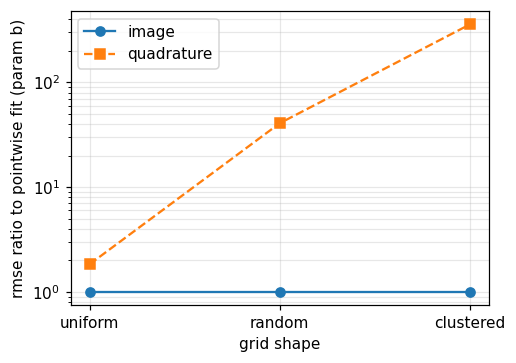

In [9]:
# ordered by how uneven the grid is, so the line runs with the claim
PLOT_GRIDS = tuple(g for g in ("uniform", "random", "clustered")
                   if g in QUAD_GRIDS)

fig, ax = plt.subplots(figsize=(4.8, 3.4))
for route, style in (("image", "o-"), ("quadrature", "s--")):
    sub = quadrature_bias[(quadrature_bias.route == route)
                          & (quadrature_bias.param == "b")]
    sub = sub.set_index("grid").reindex(PLOT_GRIDS)
    ax.semilogy(sub.index, sub.ratio_to_pointwise, style, label=route)
ax.set_ylabel("rmse ratio to pointwise fit (param b)")
ax.set_xlabel("grid shape")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
plt.show()

In [10]:
quad = quadrature_bias[quadrature_bias.route == "quadrature"].set_index(["grid", "param"])
u_ratio = quad.loc[("uniform", slice(None)), "ratio_to_pointwise"]
r_ratio = quad.loc[("random", slice(None)), "ratio_to_pointwise"] if "random" in QUAD_GRIDS else None
c_ratio = quad.loc[("clustered", slice(None)), "ratio_to_pointwise"]
c_bias = quad.loc[("clustered", slice(None)), "relative_bias_pct"]
# fails if the quadrature route does not read worse than the discrete one
# by the margins the sample statistic against the same-density quadrature
# actually shows
assert (u_ratio > 1.25).all()
if r_ratio is not None:
    assert (r_ratio > 20.0).all()
assert (c_ratio > 200.0).all()
assert (c_bias > 100.0).all()
print(f"quadrature/pointwise ratio: uniform {u_ratio.to_numpy()}, "
      + (f"random {r_ratio.to_numpy()}, " if r_ratio is not None else "")
      + f"clustered {c_ratio.to_numpy()}; clustered relative bias "
      f"{c_bias.to_numpy()} percent, against the image route's own "
      f"{quadrature_bias[(quadrature_bias.route == 'image') & (quadrature_bias.grid == 'clustered')].relative_bias_pct.to_numpy()} percent.")


quadrature/pointwise ratio: uniform [1.30787323 1.83193282], random [50.96719888 40.73587512], clustered [655.68756376 358.03418208]; clustered relative bias [176.94804963 291.53604325] percent, against the image route's own [0.0046411  0.08290122] percent.


## Where the quadrature route loses it

The uniform grid carries exactly the mean density the rescaling assumes and
still reads worse than the discrete route, so the density is not the whole
account. A sum over an evenly spaced grid is the trapezoid rule: `n / span`
times the integral misses the half weight the two end samples carry, and the
other obvious constant, `(n - 1) / span`, does not repair that either. The
cell below adds the endpoint terms to the model side and refits, on the
uniform grid and on the uneven ones, keeping the seed, the replicate count
and the data statistic of the route above so its `n / span` column is that
same route.

In [11]:
NODES, WEIGHTS = leg.leggauss(200)


def quad_model_side(p, order, span, scale, endpoints):
    xq = 0.5 * span * (NODES + 1.0)
    out = scale * (basis_mat(xq, order, span).T
                   @ (WEIGHTS * 0.5 * span * model(xq, *p)))
    if endpoints:
        ends = np.array([0.0, span])
        out = out + 0.5 * (basis_mat(ends, order, span).T @ model(ends, *p))
    return out


def fit_variant(x, y, order, span, p0, scale_n, endpoints):
    phi = basis_mat(x, order, span)
    L_ = gram_whitener(phi.T @ phi)
    rhs = np.linalg.solve(L_, phi.T @ y)
    scale = scale_n(x.size) / span

    def resid(p):
        return rhs - np.linalg.solve(
            L_, quad_model_side(p, order, span, scale, endpoints))
    return least_squares(resid, p0, method="lm").x


VARIANTS = {"n/span": (lambda n: n, False),
            "(n-1)/span": (lambda n: n - 1.0, False),
            "(n-1)/span + endpoints": (lambda n: n - 1.0, True)}

rows = []
for kind in QUAD_GRIDS:
    x0 = montecarlo.grid(kind, N, span=1.0, rng=np.random.default_rng(0))
    phi0 = basis_mat(x0, ORDER_Q, 1.0)
    L0 = gram_whitener(phi0.T @ phi0)
    d0 = np.linalg.solve(L0, phi0.T @ model(x0, *TRUTH_Q))
    mismatch = {}
    for name, (scale_n, endpoints) in VARIANTS.items():
        q0 = quad_model_side(TRUTH_Q, ORDER_Q, 1.0, scale_n(x0.size), endpoints)
        mismatch[name] = float(np.linalg.norm(d0 - np.linalg.solve(L0, q0))
                               / np.linalg.norm(d0))
    est = {name: [] for name in VARIANTS}
    pw_est = []
    for rng in montecarlo.generators(7, REPS_QUAD):
        x = montecarlo.grid(kind, N, span=1.0, rng=rng)
        y, sigma = montecarlo.noisy(model(x, *TRUTH_Q), NOISE, rng)
        pw_est.append(baselines.scipy_curve_fit(x, y, model, [1.0, -1.0]))
        for name, (scale_n, endpoints) in VARIANTS.items():
            est[name].append(fit_variant(x, y, ORDER_Q, 1.0, [1.0, -1.0],
                                         scale_n, endpoints))
    s_pw = montecarlo.summarize(np.asarray(pw_est), TRUTH_Q)
    for name in VARIANTS:
        s = montecarlo.summarize(np.asarray(est[name]), TRUTH_Q)
        ratio = np.asarray(s.rmse) / np.asarray(s_pw.rmse)
        for i, pname in enumerate(("a", "b")):
            rows.append({"grid": kind, "rescaling": name, "param": pname,
                         "model_side_mismatch": mismatch[name],
                         "ratio_to_pointwise": ratio[i]})
quadrature_rescaling = pd.DataFrame(rows)
quadrature_rescaling.pivot_table(index=["grid", "param"], columns="rescaling",
                                 values=["ratio_to_pointwise",
                                         "model_side_mismatch"])

model_side_mismatch                                   \
rescaling                (n-1)/span (n-1)/span + endpoints    n/span   
grid      param                                                        
clustered a                0.638411               0.633508  0.639341   
          b                0.638411               0.633508  0.639341   
random    a                0.220244               0.215924  0.222900   
          b                0.220244               0.215924  0.222900   
uniform   a                0.060782               0.008426  0.060670   
          b                0.060782               0.008426  0.060670   

                ratio_to_pointwise                                     
rescaling               (n-1)/span (n-1)/span + endpoints      n/span  
grid      param                                                        
clustered a             660.763835             590.761076  655.687564  
          b             358.034452             330.634364  358.034182  
random    a              50.563145              51.111323   50.967199  
          b              40.735914              40.501312   40.735875  
uniform   a               2.287859               1.000232    1.307873  
          b               1.831933               1.000614    1.831933

In [12]:
r = quadrature_rescaling.set_index(["grid", "rescaling", "param"]).ratio_to_pointwise
prev = quadrature_bias[quadrature_bias.route == "quadrature"].set_index(["grid", "param"]).ratio_to_pointwise
# fails if this cell's n/span variant is not the route measured above
assert np.allclose([r[(g, "n/span", p)] for g, p in prev.index], prev.to_numpy())
# fails if the other constant rescaling repairs the uniform grid
assert r[("uniform", "(n-1)/span", "a")] > r[("uniform", "n/span", "a")]
end_uniform = [r[("uniform", "(n-1)/span + endpoints", p)] for p in ("a", "b")]
# fails if the endpoint terms do not restore parity on the uniform grid
assert max(abs(v - 1.0) for v in end_uniform) < 0.02
uneven = [g for g in QUAD_GRIDS if g != "uniform"]
for g in uneven:
    for p in ("a", "b"):
        # fails if the endpoint terms repair a grid of varying density too
        assert r[(g, "(n-1)/span + endpoints", p)] > 20.0
        assert r[(g, "(n-1)/span + endpoints", p)] > 0.8 * r[(g, "n/span", p)]


def ratios(grid_kind, rescaling):
    return ", ".join(f"{r[(grid_kind, rescaling, p)]:.3f}" for p in ("a", "b"))


print(f"uniform grid: n/span {ratios('uniform', 'n/span')}, "
      f"(n-1)/span {ratios('uniform', '(n-1)/span')}, with the endpoint "
      f"terms {ratios('uniform', '(n-1)/span + endpoints')}.")
for g in uneven:
    print(f"{g} grid: n/span {ratios(g, 'n/span')}, with the endpoint terms "
          f"{ratios(g, '(n-1)/span + endpoints')}.")

uniform grid: n/span 1.308, 1.832, (n-1)/span 2.288, 1.832, with the endpoint terms 1.000, 1.001.
clustered grid: n/span 655.688, 358.034, with the endpoint terms 590.761, 330.634.
random grid: n/span 50.967, 40.736, with the endpoint terms 51.111, 40.501.


In [13]:
if QUICK:
    print("QUICK: skipping the CSV export")
else:
    notebook.save_table("12_discrete_image", "quadrature_bias", quadrature_bias)
    print("wrote experiments/results/12_discrete_image/quadrature_bias.csv")


wrote experiments/results/12_discrete_image/quadrature_bias.csv


## Order from 4 to 96

Above the order `order_for` reports, adding more coefficients should not
move the ratio or the coverage; below it, a family whose sensitivities need
more terms should read worse. `dtfit.fit` warns when the image's own order
is below what the model needs; that warning is shown once here, at order 4
on the oscillatory family, rather than suppressed.


In [14]:
_warned = False
rows = []
for family, (f, truth, p0, names) in CASES.items():
    mark = order_for(f, truth, (0.0, 1.0), param_names=names)
    for kind in GRIDS:
        pw_est = []
        img_est = {k: [] for k in ORDERS}
        cover = {k: np.zeros(2) for k in ORDERS}
        for rng in montecarlo.generators(11, REPS_ORDER):
            x = montecarlo.grid(kind, N, span=1.0, rng=rng)
            y, sigma = montecarlo.noisy(f(x, *truth), NOISE, rng)
            pw_est.append(baselines.scipy_curve_fit(x, y, f, p0))
            for k in ORDERS:
                with warnings.catch_warnings(record=True) as caught:
                    warnings.simplefilter("always")
                    r = dtfit.fit(f, Image.of(Original(x, y), "legendre", k),
                                  p0=p0, param_names=names)
                    if caught and not _warned:
                        print("warning shown once:", caught[0].message)
                        _warned = True
                img_est[k].append(r.coeffs)
                ci = np.asarray([r.confidence_intervals()[n] for n in names])
                cover[k] += (ci[:, 0] <= truth) & (truth <= ci[:, 1])
        s_pw = montecarlo.summarize(np.asarray(pw_est), truth)
        for k in ORDERS:
            s = montecarlo.summarize(np.asarray(img_est[k]), truth)
            ratio = np.asarray(s.rmse) / np.asarray(s_pw.rmse)
            for i, name in enumerate(names):
                rows.append({"family": family, "grid": kind, "order": k,
                             "order_for": mark, "param": name,
                             "ratio_to_pointwise": ratio[i],
                             "coverage": cover[k][i] / REPS_ORDER})
order_sweep = pd.DataFrame(rows)
order_sweep.pivot_table(index=["family", "grid", "order"], columns="param",
                         values=["ratio_to_pointwise", "coverage"])


warning shown once: image coverage 0.266 at order 4: the model's sensitivities are not represented at this order; build the image at order_for(model, p0, domain)


coverage                      \
param                                    a         b         w   
family           grid      order                                 
a*exp(b*x)       clustered 4      0.913333  0.980000       NaN   
                           8      0.913333  0.980000       NaN   
                           16     0.913333  0.980000       NaN   
                           24     0.913333  0.980000       NaN   
                           48     0.913333  0.973333       NaN   
                           96     0.913333  0.980000       NaN   
                 random    4      0.953333  0.986667       NaN   
                           8      0.953333  0.986667       NaN   
                           16     0.953333  0.986667       NaN   
                           24     0.953333  0.986667       NaN   
                           48     0.953333  0.986667       NaN   
                           96     0.953333  0.986667       NaN   
                 uniform   4      0.946667  0.986667       NaN   
                           8      0.946667  0.986667       NaN   
                           16     0.946667  0.986667       NaN   
                           24     0.946667  0.986667       NaN   
                           48     0.946667  0.986667       NaN   
                           96     0.946667  0.986667       NaN   
a*sin(w*x) decay clustered 4      1.000000       NaN  1.000000   
                           8      0.926667       NaN  0.933333   
                           16     0.926667       NaN  0.926667   
                           24     0.926667       NaN  0.926667   
                           48     0.926667       NaN  0.926667   
                           96     0.926667       NaN  0.926667   
                 random    4      1.000000       NaN  1.000000   
                           8      0.960000       NaN  0.953333   
                           16     0.960000       NaN  0.953333   
                           24     0.960000       NaN  0.953333   
                           48     0.960000       NaN  0.953333   
                           96     0.960000       NaN  0.953333   
                 uniform   4      1.000000       NaN  1.000000   
                           8      0.980000       NaN  0.946667   
                           16     0.980000       NaN  0.946667   
                           24     0.980000       NaN  0.946667   
                           48     0.980000       NaN  0.946667   
                           96     0.980000       NaN  0.946667   

                                 ratio_to_pointwise                      
param                                             a         b         w  
family           grid      order                                         
a*exp(b*x)       clustered 4               0.999978  1.000048       NaN  
                           8               1.000000  1.000000       NaN  
                           16              1.000000  1.000000       NaN  
                           24              1.000000  1.000000       NaN  
                           48              1.000001  0.999999       NaN  
                           96              1.000001  1.000002       NaN  
                 random    4               0.999944  0.999885       NaN  
                           8               1.000000  1.000000       NaN  
                           16              1.000000  1.000000       NaN  
                           24              1.000000  1.000000       NaN  
                           48              1.000000  1.000000       NaN  
                           96              1.000002  1.000002       NaN  
                 uniform   4               1.000051  1.000019       NaN  
                           8               1.000000  1.000000       NaN  
                           16              1.000000  1.000000       NaN  
                           24              1.000000  1.000000       NaN  
                           48              1.000000  

In [15]:
at_or_above = order_sweep[order_sweep.order >= order_sweep.order_for]
moved_ratio = at_or_above.groupby(["family", "grid", "param"]).ratio_to_pointwise.agg(lambda s: s.max() - s.min())
moved_cov = at_or_above.groupby(["family", "grid", "param"]).coverage.agg(lambda s: s.max() - s.min())
low_order = order_sweep[order_sweep.order == min(ORDERS)]
osc_low = low_order[low_order.family == "a*sin(w*x) decay"]
# fails if the ratio keeps moving materially from the reported order to 96
assert moved_ratio.max() < 0.01
# fails if the coverage keeps moving materially from the reported order to 96
assert moved_cov.max() < 0.03
# fails if the low-order departure does not show up on the oscillatory family
assert (osc_low.ratio_to_pointwise > 1.05).any()
print(f"from the order order_for reports to {max(ORDERS)}, the ratio moves "
      f"by at most {moved_ratio.max():.4f} and the coverage by at most "
      f"{moved_cov.max():.4f}; at order {min(ORDERS)} the oscillatory "
      f"family's ratio reaches {osc_low.ratio_to_pointwise.max():.3f} on at "
      "least one grid.")


from the order order_for reports to 96, the ratio moves by at most 0.0005 and the coverage by at most 0.0067; at order 4 the oscillatory family's ratio reaches 1.076 on at least one grid.


In [16]:
if QUICK:
    print("QUICK: skipping the CSV export")
else:
    notebook.save_table("12_discrete_image", "order_sweep", order_sweep)
    print("wrote experiments/results/12_discrete_image/order_sweep.csv")


wrote experiments/results/12_discrete_image/order_sweep.csv


The Gram conditioning by order and grid, for both bases, is notebook 13's;
the integral criterion's monomial weight matrix is notebook 11's. Neither
is remeasured here.


## Findings and limits

`Image.S` and `Image.G` are exactly the products `Phi^T y` and `Phi^T Phi`,
nothing smoothed or regularised into them: rebuilding both from the basis
evaluated on the samples matches them to 2.8e-14 and 0.0 on all three grid
shapes, machine precision. The image also carries `n`, `sumsq`, `sumy` and
`wsum` for the rest of the sufficient statistic; this section checks only
`S` and `G`. The solved coefficient is `G^-1 S`, not `S` itself, because the
samples do not make the basis orthonormal.

At the order `order_for` reports, the image fit reads like the pointwise
fit on every grid and both families: the rmse ratio never departs from
1.000 by more than 0.0005, the relative bias stays below 0.04 percent, and
the confidence intervals cover the truth in [0.94, 0.97]. The image is the
discrete statistic, not an approximation to something else.

Reading the same criterion by quadrature breaks that parity. Sharing the
data statistic and the whitening isolates the model side: evaluating the
model at 200 Gauss-Legendre nodes and rescaling by the mean sample density
reads 1.31 to 1.83 times the pointwise fit's rmse on the uniform grid,
41 to 51 times on the random grid and 358 to 656 times on the clustered
grid, where its relative bias reaches 177 to 292 percent against the image
route's own 0.005 to 0.08 percent there.

Two effects put it there, and they separate cleanly. The uniform grid has
exactly the density the rescaling assumes, so none of its loss is a density
error: a sum over an evenly spaced grid is the trapezoid rule, and no
constant rescaling carries the half weight of the two end samples -
`(n - 1) / span`, the other obvious constant, reads 2.29 on a, worse than
`n / span`'s 1.31. Adding the endpoint terms to the model side brings the
uniform grid to 1.000 and 1.001, parity with the discrete route, and its
whitened model-side mismatch at the truth from 0.061 to 0.0084. On the
uneven grids the density itself varies, no single scale is right anywhere,
and those same endpoint terms change almost nothing: 51.1 and 40.5 on the
random grid against 51.0 and 40.7, 590.8 and 330.6 on the clustered grid
against 655.7 and 358.0, with the clustered mismatch moving from 0.639 to
0.634. The second effect is the one that grows with how uneven the grid is,
and it is the one the discrete image removes.

Order above what `order_for` reports is free within the range tried here:
from that order to 96 the ratio moves by at most 0.0005 and the coverage by
at most 0.0067. Below it, the family whose sensitivities need more terms
reads worse - at order 4 the decaying oscillation's ratio reaches 1.076 on
the random grid - while the plain exponential, whose sensitivities are
already represented at order 3, does not move.

Limits: two smooth families and Gaussian noise at one sample size; the
three grid shapes are `montecarlo.grid`'s own constructions, not a sampling
pattern measured from an instrument. The endpoint correction is measured
only on this model and this order, and it is a diagnostic here, not a route
the package offers. The order sweep above holds each noise draw fixed
across all six orders to isolate the effect of order alone, so its coverage
column is not six independent measurements and is too thin at REPS_ORDER
replicates to size a coverage number on its own; the figure to read for
coverage is `grid_bias_efficiency`, at REPS_FIT replicates, which puts the
clustered grid in [0.94, 0.97] for the image route. Neither the quadrature
route nor the pointwise reference gets confidence intervals anywhere in
this notebook.

In [17]:
print(notebook.provenance(STARTED))


2026-09-20 commit bff7503 dtfit 0.4.0 dtfit-experimental 0.1.0 74.5s
